Let's import necessary libraries.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

We are wondering if there is a relationship between wine prices (unit price per liter) and ABV (alcohol by volume). First, let's read the dataset.

In [2]:
wines = pd.read_csv('data/wines.csv')

wines.sample(2, random_state=42)

,Wine,Country,UnitPrice,ABV
27,Chandon Rose Sparkling,Argentina,2086.67,12.0
15,Dugladze Saperavi Ovevri Kırmız Sek Şarap,Georgia,1473.33,13.0


Let's inspect the dataset structure, data types, and missing values.

In [3]:
wines.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Wine       30 non-null     str    
 1   Country    30 non-null     str    
 2   UnitPrice  30 non-null     float64
 3   ABV        30 non-null     float64
dtypes: float64(2), str(2)
memory usage: 1.1 KB


The dataset contains 30 observations and 4 columns. There are no missing values, and both UnitPrice and ABV are stored as float variables, which makes them suitable for correlation analysis.

---
Before jumping into correlation calculations, it makes sense to visually inspect the relationship between UnitPrice and ABV.   

Correlation metrics are designed to capture specific types of patterns. Pearson measures linear relationships, while Spearman focuses on monotonic ones.

By examining the scatter plot, we can see whether the variables move together in a linear way, follow a curved but monotonic pattern, show a more complex structure, or display no clear association at all.

This visual step helps us choose the appropriate correlation method instead of applying one mechanically.

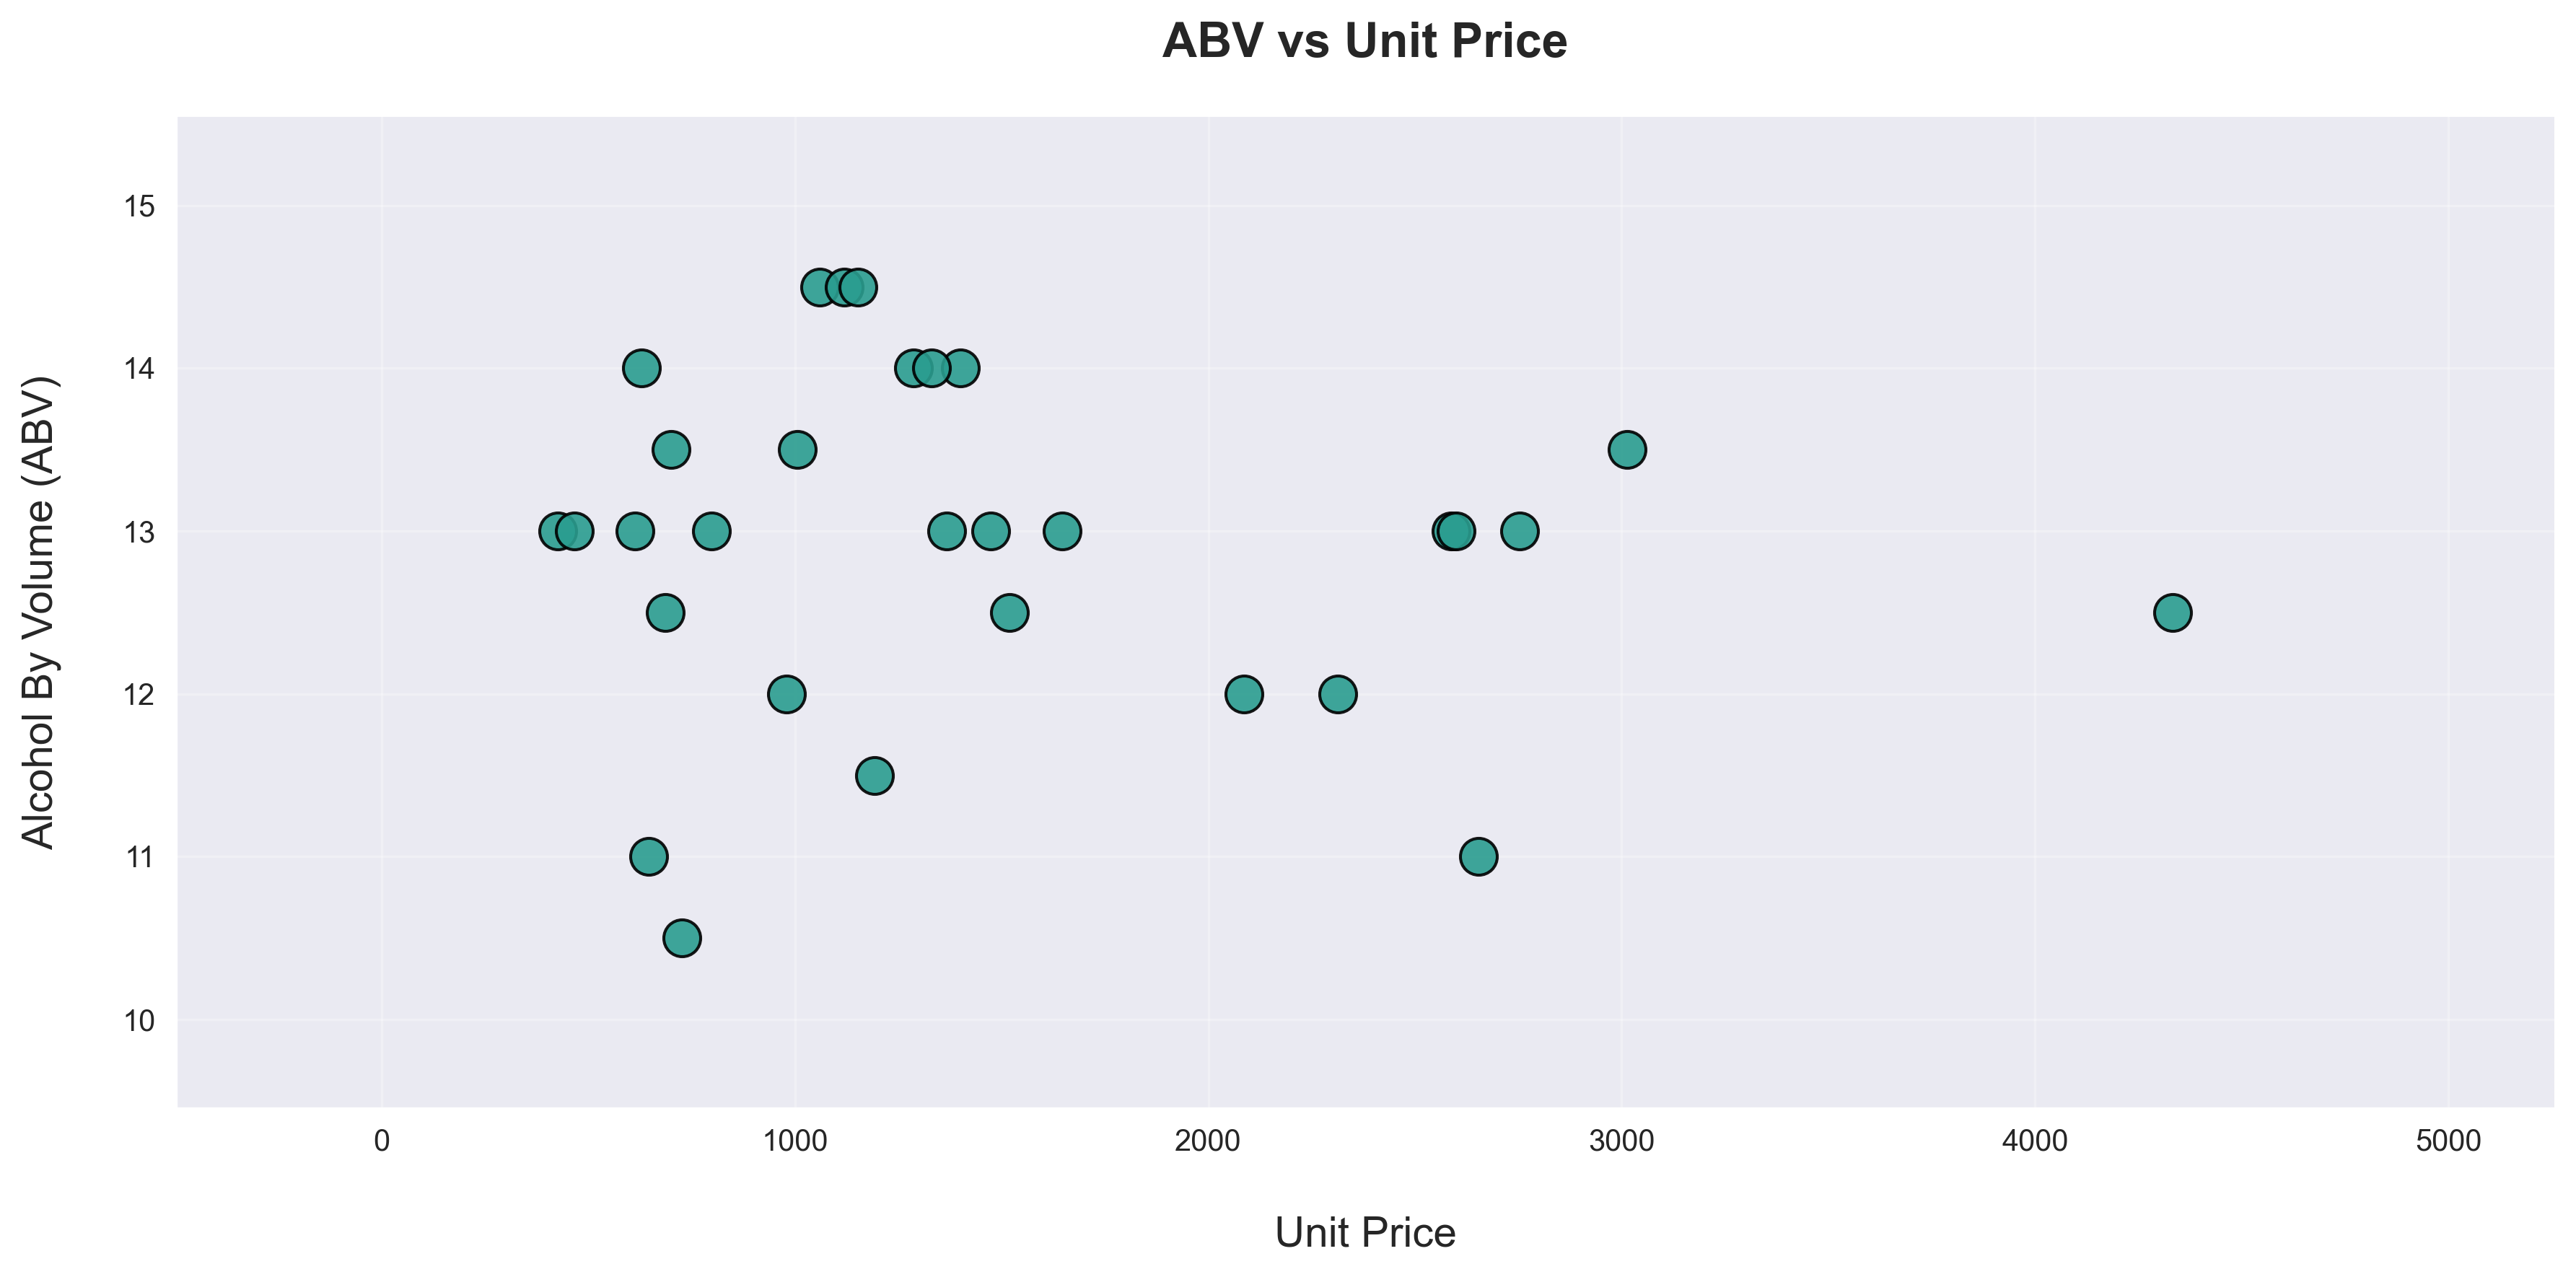

In [9]:
# Set a clean background style with visible gridlines
sns.set_style("darkgrid")

# Create a high-resolution figure 
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Create the scatter plot
# - data: dataset used
# - x / y: numerical variables being compared
# - color: point color for visual consistency
# - edgecolor: adds contrast to each point
# - s: marker size
# - alpha: transparency level to reduce overplotting
sns.scatterplot(
    data=wines,
    x="UnitPrice",
    y="ABV",
    color="#2A9D8F",
    edgecolor="black",
    s=150,
    alpha=0.9, 
    ax=ax
)

# Compute minimum, maximum, and standard deviation for dynamic axis padding
x_min = wines['UnitPrice'].min()
x_max = wines['UnitPrice'].max()
x_std = wines['UnitPrice'].std()

y_min = wines['ABV'].min()
y_max = wines['ABV'].max()
y_std = wines['ABV'].std()

# Extend axis limits by one standard deviation on both ends
# This prevents points from touching plot boundaries and improves readability
ax.set_xlim(x_min - x_std, x_max + x_std)
ax.set_ylim(y_min - y_std, y_max + y_std)

# Add descriptive title and axis labels with spacing adjustments
ax.set_title("ABV vs Unit Price", fontsize=16, weight="bold", pad=20)
ax.set_xlabel('Unit Price', fontsize=14, labelpad=20)
ax.set_ylabel('Alcohol By Volume (ABV)', fontsize=14, labelpad=20)

# Add a subtle grid for better visual guidance
ax.grid(True, alpha=0.3)

# Remove unnecessary top and right borders for a cleaner look
sns.despine()

# Automatically adjust layout to prevent overlapping elements
plt.tight_layout()

# Render the final plot
plt.show()

The scatter plot does not reveal a strong or obvious linear pattern between UnitPrice and ABV. The points appear fairly dispersed, with no clear upward or downward trend.

Nevertheless, to formally assess whether a linear relationship exists, we compute the Pearson correlation coefficient. This allows us to quantify the strength and direction of any potential linear association, even if it is not visually prominent.

In [10]:
wines[['UnitPrice', 'ABV']].corr()

,UnitPrice,ABV
UnitPrice,1.000000,-0.112418
ABV,-0.112418,1.000000


The Pearson correlation coefficient between UnitPrice and ABV is -0.11, indicating a very weak negative linear relationship.

This suggests that, within this sample, higher alcohol content is not associated with higher prices. In fact, the slight negative value implies a minimal tendency in the opposite direction, though the magnitude is too small to indicate a meaningful linear association.

Overall, ABV does not appear to be a strong linear driver of wine prices in this dataset.

In [11]:
wines[['UnitPrice', 'ABV']].corr(method='spearman')

,UnitPrice,ABV
UnitPrice,1.000000,-0.102093
ABV,-0.102093,1.000000


In [23]:
wines

,Wine,Country,UnitPrice,ABV
0,Pellehaut Kırmızı Şarap,France,1193.33,11.5
1,Finca Las Zarras Kırmızı Şarap,Spain,646.67,11.0
2,Ed Knows Cabernet Sauvignon Kırmızı Sek Şarap,Moldova,613.20,13.0
3,El Paso Kırmızı Şarap,Spain,700.00,13.5
4,Tersus Cabernet Sauvignon Kırmızı Şarap,Moldova,686.67,12.5
5,Chateau Argadens Kırmızı Şarap,France,1399.87,14.0
6,Piccini Pinocchio Kırmızı Yarı Tatlı Şarap,Italy,1366.67,13.0
7,Sevilen İsabey Cabernet Sauvignon Merlot,Türkiye,1006.67,13.5
8,Doluca Sarafin Fume Blanc,Türkiye,2753.33,13.0
9,Piccini Prosecco Doğal Köpüren Beyaz Şarap,Italy,2653.33,11.0


In [17]:
wines.groupby('Country').count()['Wine']

Country
Argentina     2
France        4
Georgia       1
Germany       1
Italy         7
Moldova       2
Spain         2
Türkiye      11
Name: Wine, dtype: int64

In [19]:
wines_tr = wines[wines.Country == 'Türkiye']

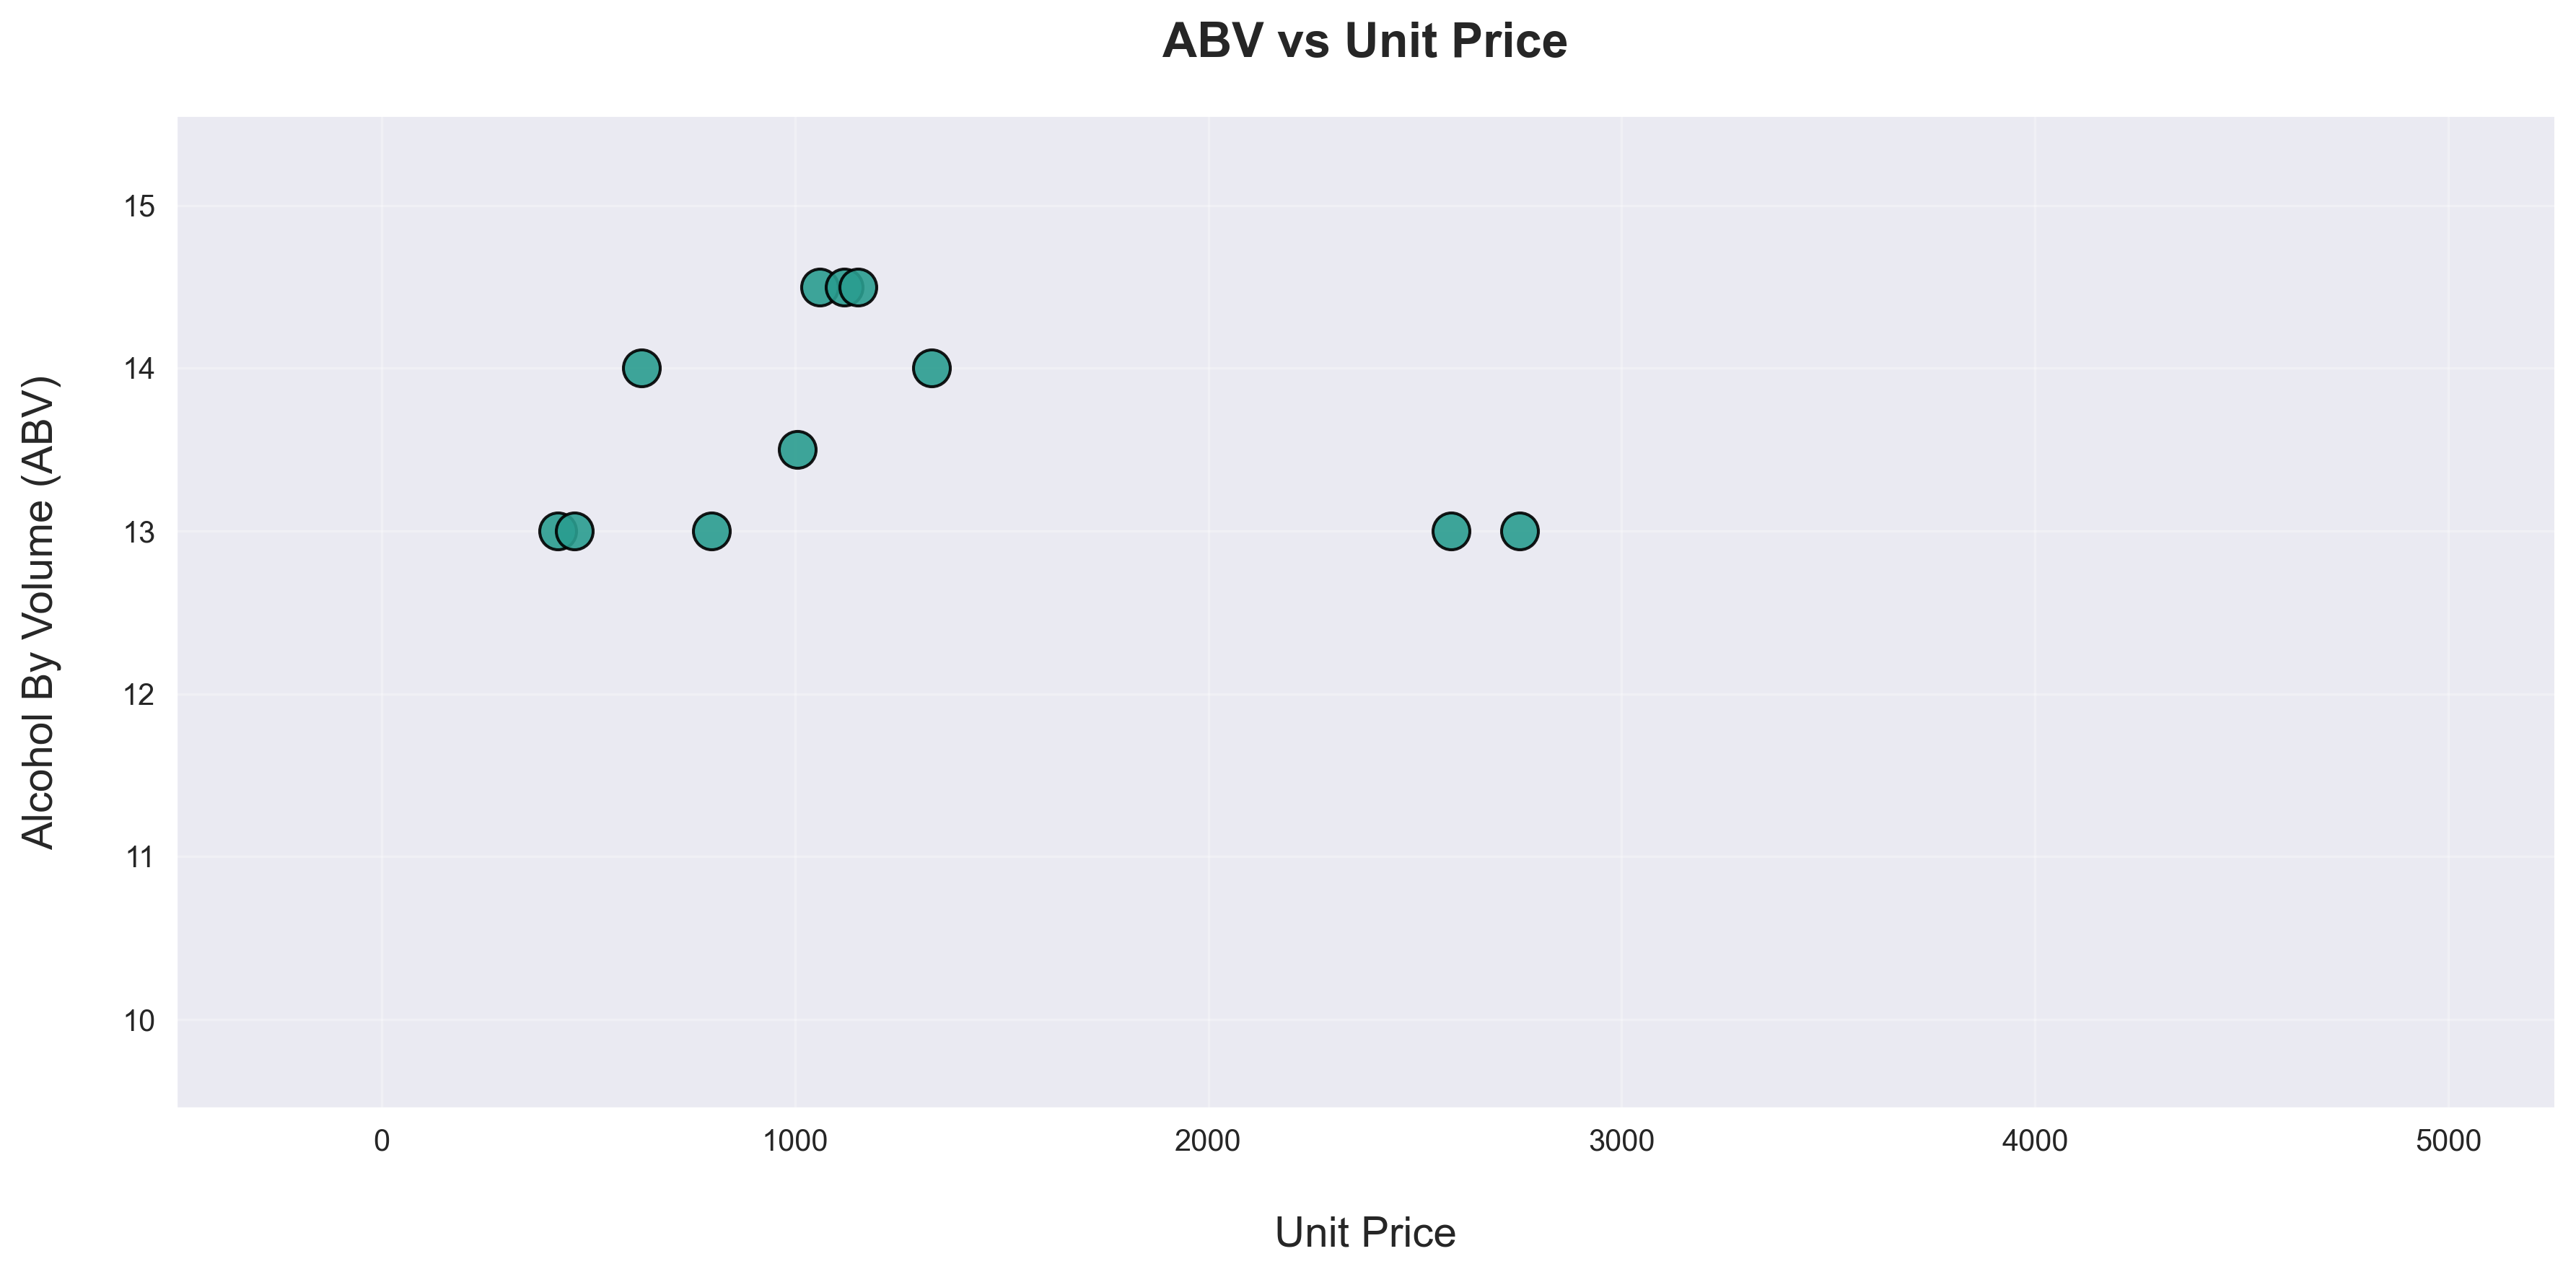

In [20]:
# Set a clean background style with visible gridlines
sns.set_style("darkgrid")

# Create a high-resolution figure 
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Create the scatter plot
# - data: dataset used
# - x / y: numerical variables being compared
# - color: point color for visual consistency
# - edgecolor: adds contrast to each point
# - s: marker size
# - alpha: transparency level to reduce overplotting
sns.scatterplot(
    data=wines_tr,
    x="UnitPrice",
    y="ABV",
    color="#2A9D8F",
    edgecolor="black",
    s=150,
    alpha=0.9, 
    ax=ax
)

# Compute minimum, maximum, and standard deviation for dynamic axis padding
x_min = wines['UnitPrice'].min()
x_max = wines['UnitPrice'].max()
x_std = wines['UnitPrice'].std()

y_min = wines['ABV'].min()
y_max = wines['ABV'].max()
y_std = wines['ABV'].std()

# Extend axis limits by one standard deviation on both ends
# This prevents points from touching plot boundaries and improves readability
ax.set_xlim(x_min - x_std, x_max + x_std)
ax.set_ylim(y_min - y_std, y_max + y_std)

# Add descriptive title and axis labels with spacing adjustments
ax.set_title("ABV vs Unit Price", fontsize=16, weight="bold", pad=20)
ax.set_xlabel('Unit Price', fontsize=14, labelpad=20)
ax.set_ylabel('Alcohol By Volume (ABV)', fontsize=14, labelpad=20)

# Add a subtle grid for better visual guidance
ax.grid(True, alpha=0.3)

# Remove unnecessary top and right borders for a cleaner look
sns.despine()

# Automatically adjust layout to prevent overlapping elements
plt.tight_layout()

# Render the final plot
plt.show()

In [22]:
wines_tr[['UnitPrice', 'ABV']].corr(method='spearman')

,UnitPrice,ABV
UnitPrice,1.00000,0.17381
ABV,0.17381,1.00000
